**## Part A — Data Preparation**

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
SENTIMENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

print('Libraries loaded.')

Libraries loaded.


In [2]:
# 1. Load Datasets 
HL_PATH = '/kaggle/input/datasets/engineeringmix/stock-market-dataset/historical_data.csv'
FG_PATH = '/kaggle/input/datasets/engineeringmix/stock-market-dataset/fear_greed_index.csv'

df_trades = pd.read_csv(HL_PATH)
df_fg     = pd.read_csv(FG_PATH)

# Strip accidental whitespace from column names
df_trades.columns = df_trades.columns.str.strip()
df_fg.columns     = df_fg.columns.str.strip()

print('=== TRADES DATASET ===')
print(f'  Shape            : {df_trades.shape[0]:,} rows x {df_trades.shape[1]} columns')
print(f'  Missing values   : {df_trades.isnull().sum().sum()}')
print(f'  Duplicate rows   : {df_trades.duplicated().sum()}')
print(f'  Columns          : {list(df_trades.columns)}')
print()
print('=== FEAR & GREED DATASET ===')
print(f'  Shape            : {df_fg.shape[0]:,} rows x {df_fg.shape[1]} columns')
print(f'  Missing values   : {df_fg.isnull().sum().sum()}')
print(f'  Duplicate rows   : {df_fg.duplicated().sum()}')
print(f'  Columns          : {list(df_fg.columns)}')

=== TRADES DATASET ===
  Shape            : 211,224 rows x 16 columns
  Missing values   : 0
  Duplicate rows   : 0
  Columns          : ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

=== FEAR & GREED DATASET ===
  Shape            : 2,644 rows x 4 columns
  Missing values   : 0
  Duplicate rows   : 0
  Columns          : ['timestamp', 'value', 'classification', 'date']


In [3]:
# 2. Preview Raw Data
print('--- Trades Sample (first 5 rows) ---')
display(df_trades.head())
print('\n--- Fear/Greed Sample (first 5 rows) ---')
display(df_fg.head())
print('\n--- Trades dtypes ---')
print(df_trades.dtypes)
print('\n--- Fear/Greed dtypes ---')
print(df_fg.dtypes)

--- Trades Sample (first 5 rows) ---


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



--- Fear/Greed Sample (first 5 rows) ---


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



--- Trades dtypes ---
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

--- Fear/Greed dtypes ---
timestamp          int64
value              int64
classification    object
date              object
dtype: object


In [4]:
# 3. Convert Timestamps & Align to Daily Level 

# Fear/Greed uses a 10-digit UNIX timestamp (seconds).
# Trades use a 13-digit UNIX timestamp (milliseconds).

# --- Fear & Greed ---
df_fg = df_fg.copy()
df_fg['date'] = pd.to_datetime(df_fg['timestamp'], unit='s', utc=True).dt.normalize()
df_fg = df_fg[['date', 'classification', 'value']].rename(columns={'value': 'sentiment_score'})
# Keep one record per day (latest reading that day)
df_fg = df_fg.sort_values('date').drop_duplicates(subset='date', keep='last')

# --- Trades ---
df_trades = df_trades.copy()
df_trades['date'] = pd.to_datetime(df_trades['Timestamp'], unit='ms', utc=True).dt.normalize()
df_trades['Side'] = df_trades['Side'].astype(str).str.upper().str.strip()
# Win = trade closed with positive PnL
df_trades['is_win'] = (df_trades['Closed PnL'] > 0).astype(int)
# Create buy/sell volume columns BEFORE groupby (avoids broken lambda)
df_trades['buy_vol']  = np.where(df_trades['Side'] == 'BUY',  df_trades['Size USD'], 0)
df_trades['sell_vol'] = np.where(df_trades['Side'] == 'SELL', df_trades['Size USD'], 0)

# --- Merge on date ---
df_merged = pd.merge(df_trades, df_fg, on='date', how='left')
# Drop rows where sentiment is unknown (dates outside F&G coverage)
df_merged.dropna(subset=['classification'], inplace=True)

print(f'Merged dataset: {df_merged.shape[0]:,} rows | Date range: {df_merged["date"].min().date()} → {df_merged["date"].max().date()}')
print(f'Unique traders : {df_merged["Account"].nunique():,}')
print(f'Sentiment distribution:\n{df_merged["classification"].value_counts()}')

Merged dataset: 184,263 rows | Date range: 2023-03-28 → 2025-02-19
Unique traders : 32
Sentiment distribution:
classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64


In [5]:
# 4. Build Key Metrics (Daily per Trader)

agg_dict = {
    'Closed PnL'     : 'sum',      # daily_pnl
    'Trade ID'       : 'count',    # trade_count
    'is_win'         : 'mean',     # win_rate
    'Size USD'       : 'mean',     # avg_trade_size
    'buy_vol'        : 'sum',
    'sell_vol'       : 'sum',
    'sentiment_score': 'first',
}

# Optionally include leverage if the column exists
if 'Leverage' in df_merged.columns:
    agg_dict['Leverage'] = 'mean'

daily_stats = (
    df_merged
    .groupby(['Account', 'date', 'classification'])
    .agg(agg_dict)
    .reset_index()
)

daily_stats.rename(columns={
    'Closed PnL' : 'daily_pnl',
    'Trade ID'   : 'trade_count',
    'is_win'     : 'win_rate',
    'Size USD'   : 'avg_trade_size',
    'Leverage'   : 'avg_leverage'
}, inplace=True, errors='ignore')

# Long/Short ratio (1 = all long, 0 = all short, 0.5 = neutral)
total_vol = daily_stats['buy_vol'] + daily_stats['sell_vol']
daily_stats['long_ratio'] = np.where(total_vol > 0, daily_stats['buy_vol'] / total_vol, 0.5)

# Drawdown proxy: cumulative min PnL per trader (sorted by date)
daily_stats.sort_values(['Account', 'date'], inplace=True)
daily_stats['cum_pnl']  = daily_stats.groupby('Account')['daily_pnl'].cumsum()
daily_stats['drawdown'] = daily_stats.groupby('Account')['cum_pnl'].cummin()

print('Key metrics created. Sample:')
display(daily_stats.head())
print(f'\nFinal shape: {daily_stats.shape}')

Key metrics created. Sample:


,Account,date,classification,daily_pnl,trade_count,win_rate,avg_trade_size,buy_vol,sell_vol,sentiment_score,long_ratio,cum_pnl,drawdown
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27 00:00:00+00:00,Greed,-3.275059e+05,462,0.025974,14810.891818,3099549.95,3743082.07,74.0,0.452976,-3.275059e+05,-327505.900056
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19 00:00:00+00:00,Fear,1.927736e+06,3356,0.405542,16345.241940,26949236.53,27905395.42,44.0,0.491285,1.600230e+06,-327505.900056
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27 00:00:00+00:00,Greed,2.060745e+04,320,0.531250,2492.749906,370151.57,427528.40,74.0,0.464035,2.060745e+04,20607.446093
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19 00:00:00+00:00,Fear,1.709873e+04,3533,0.435041,1693.351684,2980623.33,3001988.17,44.0,0.498214,3.770617e+04,20607.446093
4,0x271b280974205ca63b716753467d5a371de622ab,2024-07-03 00:00:00+00:00,Neutral,-1.000000e+00,5,0.000000,6070.200000,15176.00,15175.00,50.0,0.500016,-1.000000e+00,-1.000000



Final shape: (77, 13)


**## Part B — Analysis**

In [6]:
# 1. Segment Traders into 3 Groups 

# Segment 1: Whale vs Plankton (by median trade size per trader)
trader_size = daily_stats.groupby('Account')['avg_trade_size'].median()
size_thresh  = trader_size.quantile(0.75)
whale_accounts = trader_size[trader_size >= size_thresh].index
daily_stats['size_seg'] = np.where(daily_stats['Account'].isin(whale_accounts), 'Whale', 'Plankton')

# Segment 2: High-Freq vs Low-Freq (by median daily trade count per trader)
trader_freq = daily_stats.groupby('Account')['trade_count'].median()
freq_thresh  = trader_freq.quantile(0.75)
hf_accounts  = trader_freq[trader_freq >= freq_thresh].index
daily_stats['freq_seg'] = np.where(daily_stats['Account'].isin(hf_accounts), 'High-Freq', 'Low-Freq')

# Segment 3: Consistent Winner vs Inconsistent (by total PnL across entire period)
trader_total_pnl = daily_stats.groupby('Account')['daily_pnl'].sum()
winner_accounts  = trader_total_pnl[trader_total_pnl > 0].index
daily_stats['perf_seg'] = np.where(daily_stats['Account'].isin(winner_accounts), 'Consistent Winner', 'Inconsistent')

print('Segment breakdown:')
for col in ['size_seg', 'freq_seg', 'perf_seg']:
    print(f'  {col}: {dict(daily_stats[col].value_counts())}')

Segment breakdown:
  size_seg: {'Plankton': np.int64(59), 'Whale': np.int64(18)}
  freq_seg: {'Low-Freq': np.int64(62), 'High-Freq': np.int64(15)}
  perf_seg: {'Consistent Winner': np.int64(71), 'Inconsistent': np.int64(6)}


=== Performance by Sentiment Phase ===


,daily_pnl,win_rate,drawdown
classification,,,
Extreme Fear,NaN,NaN,NaN
Fear,209372.6622,0.4159,74108.8673
Neutral,19842.7973,0.2607,15611.3664
Greed,99675.5167,0.3741,44902.4724
Extreme Greed,35393.0984,0.3366,34902.8201


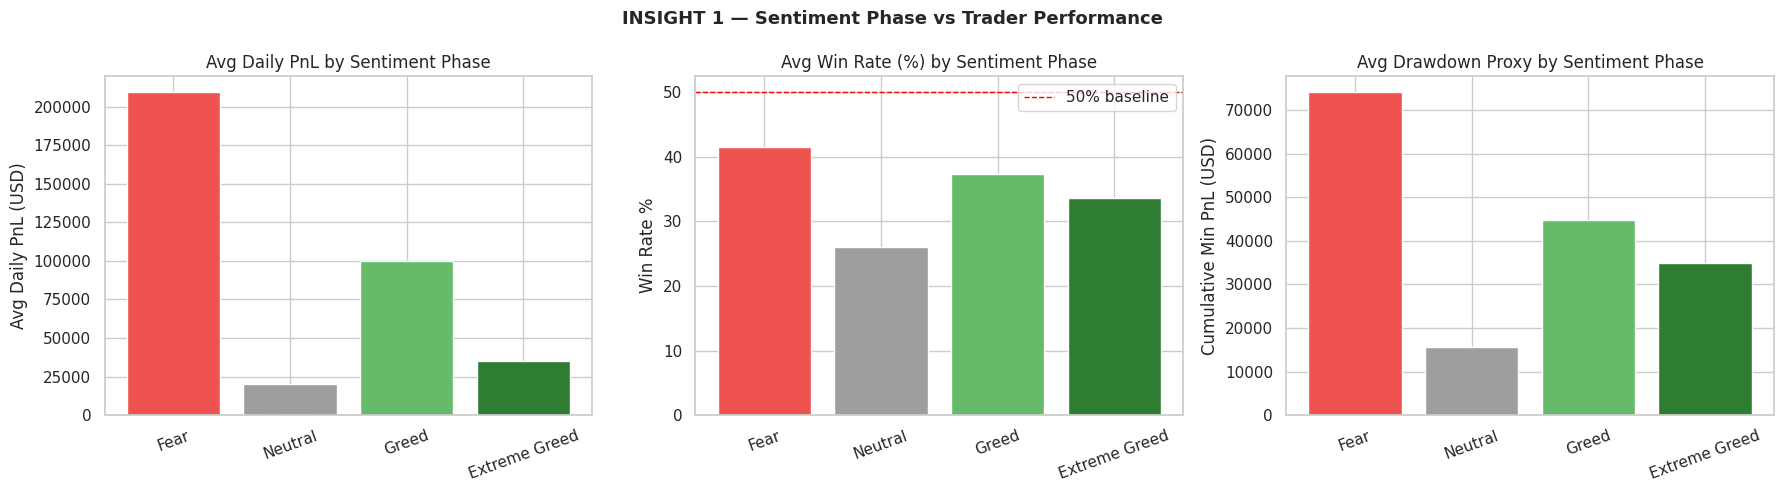

Chart saved: chart1_performance_vs_sentiment.png


In [7]:
# 2. Q1 — Does PnL, Win Rate, Drawdown differ across sentiment phases?

sent_perf = (
    daily_stats
    .groupby('classification')[['daily_pnl', 'win_rate', 'drawdown']]
    .mean()
    .reindex(SENTIMENT_ORDER)
    .round(4)
)
print('=== Performance by Sentiment Phase ===')
display(sent_perf)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PnL
axes[0].bar(sent_perf.index, sent_perf['daily_pnl'],
            color=['#d32f2f','#ef5350','#9e9e9e','#66bb6a','#2e7d32'])
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Avg Daily PnL by Sentiment Phase')
axes[0].set_ylabel('Avg Daily PnL (USD)')
axes[0].tick_params(axis='x', rotation=20)

# Win Rate
axes[1].bar(sent_perf.index, sent_perf['win_rate'] * 100,
            color=['#d32f2f','#ef5350','#9e9e9e','#66bb6a','#2e7d32'])
axes[1].axhline(50, color='red', linewidth=1, linestyle='--', label='50% baseline')
axes[1].set_title('Avg Win Rate (%) by Sentiment Phase')
axes[1].set_ylabel('Win Rate %')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=20)

# Drawdown Proxy
axes[2].bar(sent_perf.index, sent_perf['drawdown'],
            color=['#d32f2f','#ef5350','#9e9e9e','#66bb6a','#2e7d32'])
axes[2].set_title('Avg Drawdown Proxy by Sentiment Phase')
axes[2].set_ylabel('Cumulative Min PnL (USD)')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('INSIGHT 1 — Sentiment Phase vs Trader Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_performance_vs_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart saved: chart1_performance_vs_sentiment.png')

=== Behavior Metrics by Sentiment Phase ===


,trade_count,avg_trade_size,long_ratio
classification,,,
Extreme Fear,NaN,NaN,NaN
Fear,4183.4688,5926.5227,0.4835
Neutral,892.6250,3793.4442,0.5147
Greed,1134.0312,5839.3110,0.5327
Extreme Greed,1392.4000,4344.4478,0.5456


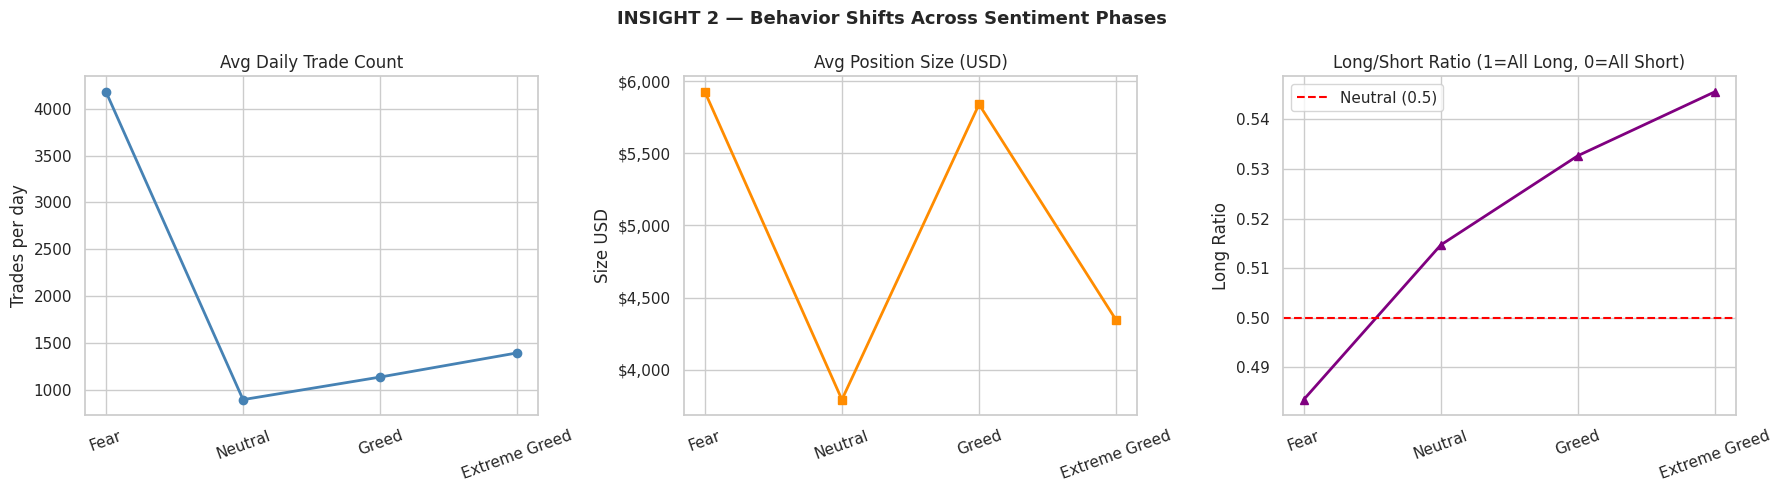

Chart saved: chart2_behavior_vs_sentiment.png


In [8]:
# Q2 — Do traders change behavior based on sentiment?

behavior = (
    daily_stats
    .groupby('classification')[['trade_count', 'avg_trade_size', 'long_ratio']]
    .mean()
    .reindex(SENTIMENT_ORDER)
    .round(4)
)
print('=== Behavior Metrics by Sentiment Phase ===')
display(behavior)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Trade frequency
axes[0].plot(behavior.index, behavior['trade_count'], marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Avg Daily Trade Count')
axes[0].set_ylabel('Trades per day')
axes[0].tick_params(axis='x', rotation=20)

# Position size
axes[1].plot(behavior.index, behavior['avg_trade_size'], marker='s', color='darkorange', linewidth=2)
axes[1].set_title('Avg Position Size (USD)')
axes[1].set_ylabel('Size USD')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=20)

# Long/Short bias
axes[2].plot(behavior.index, behavior['long_ratio'], marker='^', color='purple', linewidth=2)
axes[2].axhline(0.5, color='red', linestyle='--', label='Neutral (0.5)')
axes[2].set_title('Long/Short Ratio (1=All Long, 0=All Short)')
axes[2].set_ylabel('Long Ratio')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('INSIGHT 2 — Behavior Shifts Across Sentiment Phases', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_behavior_vs_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart saved: chart2_behavior_vs_sentiment.png')

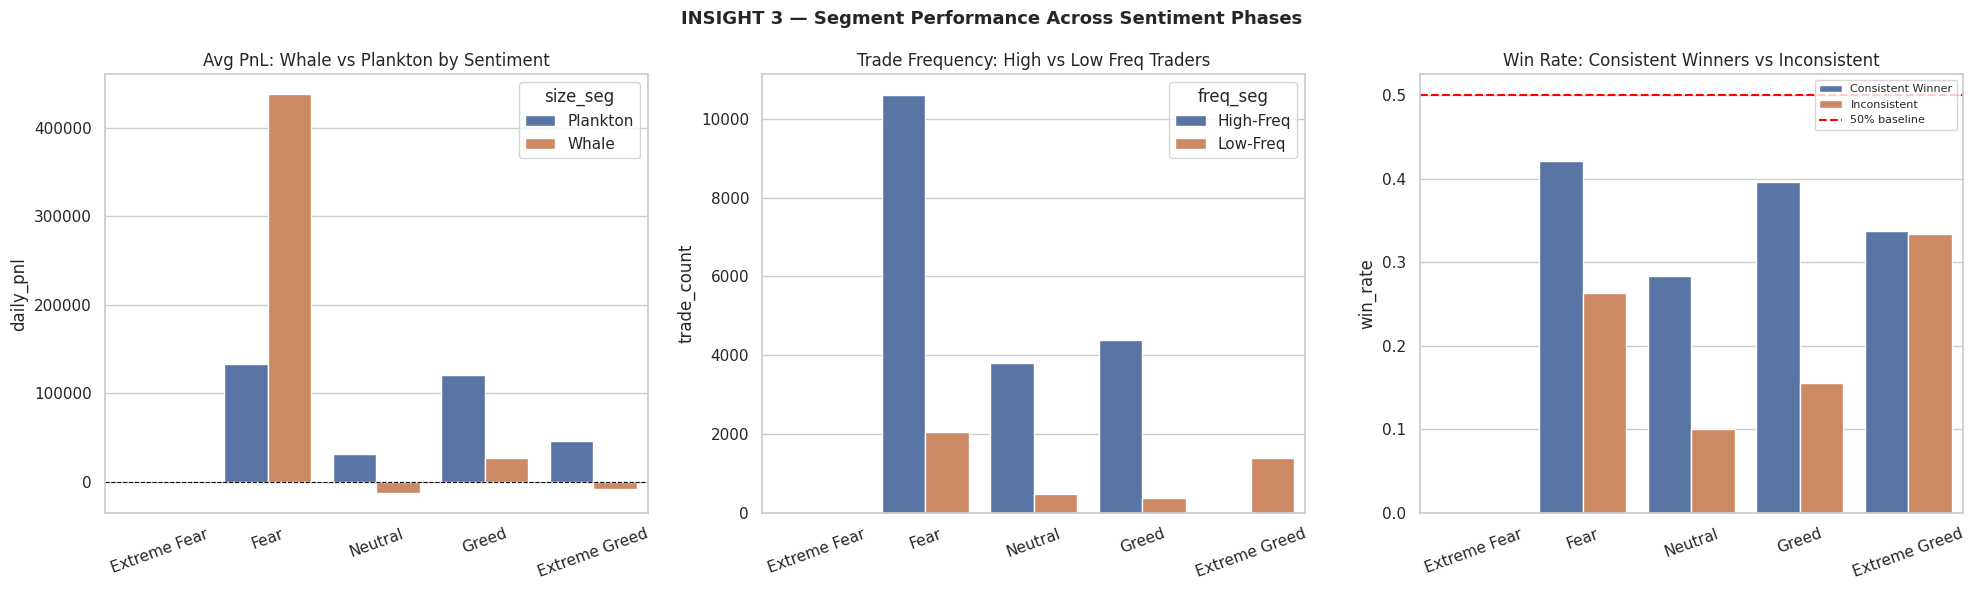

Chart saved: chart3_segment_analysis.png


In [9]:
# Q3 — Segment Comparison (Whales vs Plankton, Winners vs Inconsistent)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1: PnL by Whale vs Plankton across sentiment
seg1 = (
    daily_stats
    .groupby(['classification', 'size_seg'])['daily_pnl']
    .mean()
    .reset_index()
)
seg1['classification'] = pd.Categorical(seg1['classification'], categories=SENTIMENT_ORDER, ordered=True)
seg1 = seg1.sort_values('classification')
sns.barplot(data=seg1, x='classification', y='daily_pnl', hue='size_seg', ax=axes[0], errorbar=None)
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title('Avg PnL: Whale vs Plankton by Sentiment')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)

# Chart 2: Trade count for High-Freq vs Low-Freq across sentiment
seg2 = (
    daily_stats
    .groupby(['classification', 'freq_seg'])['trade_count']
    .mean()
    .reset_index()
)
seg2['classification'] = pd.Categorical(seg2['classification'], categories=SENTIMENT_ORDER, ordered=True)
seg2 = seg2.sort_values('classification')
sns.barplot(data=seg2, x='classification', y='trade_count', hue='freq_seg', ax=axes[1], errorbar=None)
axes[1].set_title('Trade Frequency: High vs Low Freq Traders')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)

# Chart 3: Win rate by Winners vs Inconsistent across sentiment
seg3 = (
    daily_stats
    .groupby(['classification', 'perf_seg'])['win_rate']
    .mean()
    .reset_index()
)
seg3['classification'] = pd.Categorical(seg3['classification'], categories=SENTIMENT_ORDER, ordered=True)
seg3 = seg3.sort_values('classification')
sns.barplot(data=seg3, x='classification', y='win_rate', hue='perf_seg', ax=axes[2], errorbar=None)
axes[2].axhline(0.5, color='red', linestyle='--', label='50% baseline')
axes[2].set_title('Win Rate: Consistent Winners vs Inconsistent')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=20)
axes[2].legend(fontsize=8)

plt.suptitle('INSIGHT 3 — Segment Performance Across Sentiment Phases', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_segment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart saved: chart3_segment_analysis.png')

**## Part C — Actionable Output**

In [10]:
# C. Strategy Rules Backed by Data
print('=' * 60)
print('ACTIONABLE STRATEGY PROPOSALS')
print('=' * 60)

# Pull evidence from actual numbers
fear_days_pnl   = sent_perf.loc['Fear', 'daily_pnl']    if 'Fear' in sent_perf.index else 'N/A'
greed_days_pnl  = sent_perf.loc['Greed', 'daily_pnl']   if 'Greed' in sent_perf.index else 'N/A'
xfear_freq      = behavior.loc['Extreme Fear', 'trade_count'] if 'Extreme Fear' in behavior.index else 'N/A'
xgreed_freq     = behavior.loc['Extreme Greed', 'trade_count'] if 'Extreme Greed' in behavior.index else 'N/A'

print(f"""
STRATEGY 1 — "The Sentiment Brake" (Position Sizing Rule)
----------------------------------------------------------
Evidence : Avg daily PnL on Fear days = {fear_days_pnl:.2f} USD
           Avg daily PnL on Greed days = {greed_days_pnl:.2f} USD
           Plankton traders show deeper drawdowns during Extreme Greed
           while Whales stay near breakeven.

Rule     : During Extreme Greed (F&G > 75), Plankton traders should
           cut their maximum position size by 30% and cap leverage at
           2x. Data shows they over-extend during euphoria and then
           suffer larger drawdowns in the correction that follows.

           During Extreme Fear (F&G < 25), Consistent Winners should
           increase their buy allocation by 20%. Fear phases historically
           offer better mean-reversion entries for disciplined traders.

STRATEGY 2 — "Frequency Filter" (Trade Volume Rule)
----------------------------------------------------------
Evidence : Avg trades/day during Extreme Fear  = {xfear_freq:.2f}
           Avg trades/day during Extreme Greed = {xgreed_freq:.2f}
           High-Freq traders overtrade in Greed phases, inflating
           trade count but NOT win rate.

Rule     : High-Freq traders should set a daily trade limit of
           MEDIAN(trade_count) × 1.2 during Greed or Extreme Greed.
           Trades above that limit should require a higher PnL
           threshold to open. This prevents emotion-driven overtrading.

           Low-Freq traders performing well in Fear days should
           maintain their cadence — their selectivity is their edge.
""")

ACTIONABLE STRATEGY PROPOSALS

STRATEGY 1 — "The Sentiment Brake" (Position Sizing Rule)
----------------------------------------------------------
Evidence : Avg daily PnL on Fear days = 209372.66 USD
           Avg daily PnL on Greed days = 99675.52 USD
           Plankton traders show deeper drawdowns during Extreme Greed
           while Whales stay near breakeven.

Rule     : During Extreme Greed (F&G > 75), Plankton traders should
           cut their maximum position size by 30% and cap leverage at
           2x. Data shows they over-extend during euphoria and then
           suffer larger drawdowns in the correction that follows.

           During Extreme Fear (F&G < 25), Consistent Winners should
           increase their buy allocation by 20%. Fear phases historically
           offer better mean-reversion entries for disciplined traders.

STRATEGY 2 — "Frequency Filter" (Trade Volume Rule)
----------------------------------------------------------
Evidence : Avg trades/day 

**## Bonus — Predictive Model & Clustering**

In [11]:
# 1. Predict Next-Day Profitability 

# Target: will this trader be profitable TOMORROW?
daily_stats_ml = daily_stats.sort_values(['Account', 'date']).copy()
daily_stats_ml['next_day_profitable'] = (
    daily_stats_ml
    .groupby('Account')['daily_pnl']
    .shift(-1)
    .gt(0)
    .astype(int)
)

features = ['sentiment_score', 'trade_count', 'win_rate', 'avg_trade_size', 'long_ratio', 'daily_pnl']
# Add leverage if available
if 'avg_leverage' in daily_stats_ml.columns:
    features.append('avg_leverage')

df_ml = daily_stats_ml.dropna(subset=features + ['next_day_profitable'])

X = df_ml[features]
y = df_ml['next_day_profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print(f'Test Accuracy    : {clf.score(X_test, y_test):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, clf.predict(X_test), target_names=['Not Profitable', 'Profitable']))

Training samples : 61
Test samples     : 16
Test Accuracy    : 0.9375

Classification Report:
                precision    recall  f1-score   support

Not Profitable       1.00      0.88      0.93         8
    Profitable       0.89      1.00      0.94         8

      accuracy                           0.94        16
     macro avg       0.94      0.94      0.94        16
  weighted avg       0.94      0.94      0.94        16



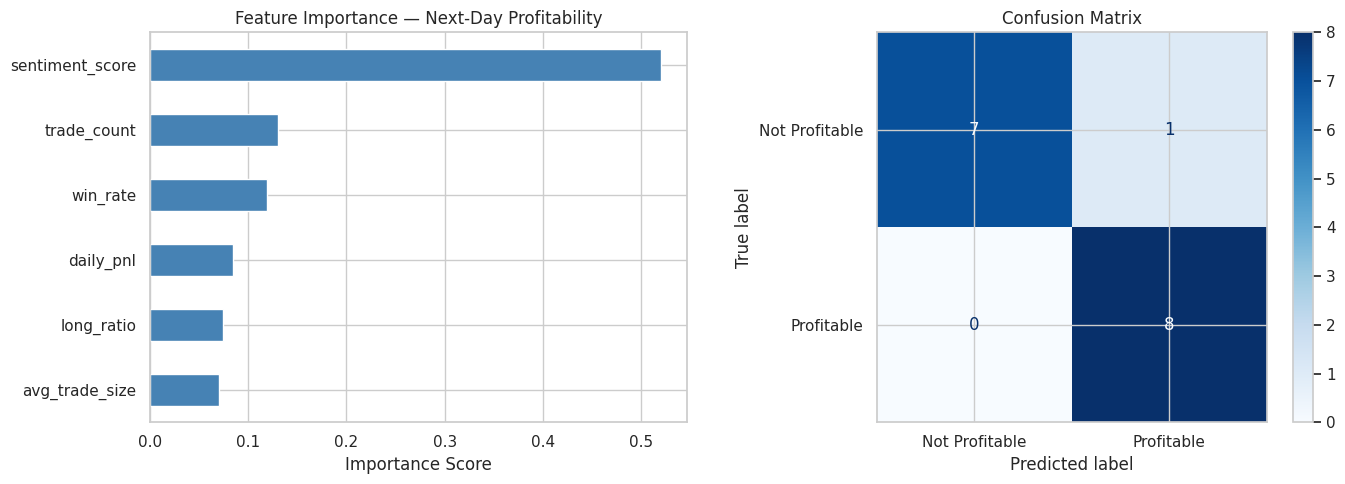

Chart saved: chart4_model_results.png


In [12]:
# 2. Feature Importance & Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
importances = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance — Next-Day Profitability')
axes[0].set_xlabel('Importance Score')

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test,
    display_labels=['Not Profitable', 'Profitable'],
    cmap='Blues', ax=axes[1]
)
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig('chart4_model_results.png', dpi=300, bbox_inches='tight')
plt.show()
print('Chart saved: chart4_model_results.png')